In [21]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 및 폰트 통합 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자라면 'AppleGothic'으로 변경
        "axes.unicode_minus": False     
    }
)

# ==========================================
# 2. 경로 및 환경 변수 세팅
# ==========================================
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3")
os.makedirs(SAVE_DIR, exist_ok=True)

MODELS = {
    "Llama-3.2-1B-Instruct": {"layers": 16},
    "Qwen2.5-1.5B-Instruct": {"layers": 28}
}

BIT_LEVELS = ["Original_BF16", "GPTQ_8bit", "GPTQ_4bit", "GPTQ_3bit", "GPTQ_2bit"]

# ==========================================
# 3. 데이터 로드 및 차분(Delta) 연산 유틸리티
# ==========================================
def load_layer_statistics(model_name, bit_suffix, prompt_dir):
    """특정 프롬프트(P1 또는 P3)의 layer_statistics.json을 읽어 DataFrame 반환 (방탄 로직 적용)"""
    folder_name = f"{model_name}_{bit_suffix}"
    json_path = os.path.join(BASE_DIR, folder_name, prompt_dir, "layer_statistics.json")
    
    if not os.path.exists(json_path):
        print(f"Warning: Data not found at {json_path}")
        return pd.DataFrame()
        
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    parsed_data = []
    
    # [방탄 파싱 로직]
    if 'layers' in data and isinstance(data['layers'], list):
        for item in data['layers']:
            if 'module_for_decoder_layer' in item:
                parsed_data.append({
                    "layer": int(item['module_for_decoder_layer']),
                    "attn_l2": item.get('attn_global_l2_norm', 0.0),
                    "mlp_l2": item.get('mlp_global_l2_norm', 0.0)
                })
    elif isinstance(data, dict):
        for key, layer_info in data.items():
            if str(key).isdigit() and isinstance(layer_info, dict): 
                parsed_data.append({
                    "layer": int(key),
                    "attn_l2": layer_info.get("attn_global_l2_norm", 0.0),
                    "mlp_l2": layer_info.get("mlp_global_l2_norm", 0.0)
                })

    if not parsed_data:
        return pd.DataFrame()
        
    return pd.DataFrame(parsed_data).sort_values(by="layer")

def get_delta_dataframe(model_name, bit_suffix):
    """P1 대비 P3의 차분(Delta) 데이터프레임을 생성합니다 (Delta = P3 - P1)"""
    df_p1 = load_layer_statistics(model_name, bit_suffix, "Prompt_01")
    df_p3 = load_layer_statistics(model_name, bit_suffix, "Prompt_03")
    
    if df_p1.empty or df_p3.empty:
        return pd.DataFrame()
        
    # Layer를 기준으로 병합
    df_merged = pd.merge(df_p1, df_p3, on="layer", suffixes=("_p1", "_p3"))
    
    # Delta (차분) 계산: 포맷 강제가 유발한 '추가적인 부하'
    df_merged["delta_attn"] = df_merged["attn_l2_p3"] - df_merged["attn_l2_p1"]
    df_merged["delta_mlp"] = df_merged["mlp_l2_p3"] - df_merged["mlp_l2_p1"]
    
    return df_merged

# ==========================================
# 4. 시각화 1: Model-wise Delta Attention Error Spike (3-bit)
# ==========================================
def plot_delta_attn_spike_3bit():
    plt.figure(figsize=(12, 6))
    colors = {"Llama-3.2-1B-Instruct": "blue", "Qwen2.5-1.5B-Instruct": "purple"}
    
    for model_name in MODELS.keys():
        df_delta = get_delta_dataframe(model_name, "GPTQ_3bit")
        if df_delta.empty: continue
            
        plt.plot(df_delta["layer"], df_delta["delta_attn"], 
                 label=f"{model_name}", color=colors[model_name], 
                 marker='o', linewidth=2.5)

    plt.title("[P3 vs P1] Formatting Tax: Delta Attention Error (3-bit)", fontsize=15, fontweight='bold')
    plt.xlabel("Layer Depth")
    plt.ylabel("$\Delta$ Attention L2 Error (P3 - P1)")
    plt.axhline(y=0, color='black', linestyle='--', linewidth=1) # 0 기준선
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig1_P3_Delta_Attn_Spike.png"), dpi=300)
    plt.close()

# ==========================================
# 5. 시각화 2: Qwen 3-bit 내부 Delta Attn vs Delta MLP 대조
# ==========================================
def plot_qwen_delta_comparison():
    target_model = "Qwen2.5-1.5B-Instruct"
    df_delta = get_delta_dataframe(target_model, "GPTQ_3bit")
    
    if df_delta.empty: return
    
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(df_delta["layer"]))
    width = 0.4
    
    # 막대 그래프 그리기
    ax.bar(x - width/2, df_delta["delta_attn"], width, label='$\Delta$ Attention Error (포맷 부하)', color='red', alpha=0.8)
    ax.bar(x + width/2, df_delta["delta_mlp"], width, label='$\Delta$ MLP Error (논리 부하)', color='blue', alpha=0.5)
    
    ax.set_title(f"[{target_model}] Formatting Tax Impact: Attn vs MLP (3-bit)", fontsize=15, fontweight='bold')
    ax.set_xlabel("Layer Depth")
    ax.set_ylabel("Error Increase ($\Delta$ P3 - P1)")
    ax.set_xticks(x)
    ax.set_xticklabels(df_delta["layer"])
    ax.legend()
    ax.grid(True, axis='y', linestyle="--", alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig2_P3_Qwen_Delta_Comparison.png"), dpi=300)
    plt.close()

# ==========================================
# 6. 시각화 3: Qwen Bit-wise Delta Attention Heatmap
# ==========================================
def plot_qwen_bitwise_heatmap():
    target_model = "Qwen2.5-1.5B-Instruct"
    heatmap_data = []
    y_labels = []
    
    # 16-bit부터 3-bit까지만 역순으로 추출 (2-bit는 Dead 상태일 수 있으므로 제외 권장, 필요시 포함)
    target_bits = ["GPTQ_3bit", "GPTQ_4bit", "GPTQ_8bit", "Original_BF16"] 
    
    for bit in target_bits:
        df_delta = get_delta_dataframe(target_model, bit)
        if not df_delta.empty:
            heatmap_data.append(df_delta["delta_attn"].values)
            y_labels.append(bit.replace("Original_", "").replace("GPTQ_", ""))
            layers = df_delta["layer"].values # X축 라벨용
            
    if not heatmap_data: return

    plt.figure(figsize=(14, 4))
    sns.heatmap(heatmap_data, cmap="Reds", center=0,
                yticklabels=y_labels, xticklabels=layers,
                cbar_kws={'label': '$\Delta$ Attention Error'})
                
    plt.title(f"[{target_model}] Bit-wise Formatting Tax Accumulation (Heatmap)", fontsize=15, fontweight='bold')
    plt.xlabel("Layer Depth")
    plt.ylabel("Quantization Bit Level")
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig3_P3_Qwen_Bitwise_Heatmap.png"), dpi=300)
    plt.close()

# ==========================================
# 7. 실행 엔진
# ==========================================
if __name__ == "__main__":
    print("P3 포맷 강제성(Formatting Tax) 차분 분석 파이프라인 가동 중...")
    
    print(" 1/3. Cross-Model Delta Attention Spike 그래프 생성 중...")
    plot_delta_attn_spike_3bit()
    
    print(" 2/3. Qwen Delta Attn vs MLP 막대그래프 생성 중...")
    plot_qwen_delta_comparison()
    
    print(" 3/3. Qwen Bit-wise Heatmap 생성 중...")
    plot_qwen_bitwise_heatmap()
    
    print(f"\n분석 완료! 시각화 이미지가 '{SAVE_DIR}'에 안전하게 저장되었습니다.")

P3 포맷 강제성(Formatting Tax) 차분 분석 파이프라인 가동 중...
 1/3. Cross-Model Delta Attention Spike 그래프 생성 중...
 2/3. Qwen Delta Attn vs MLP 막대그래프 생성 중...
 3/3. Qwen Bit-wise Heatmap 생성 중...

분석 완료! 시각화 이미지가 'D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P3'에 안전하게 저장되었습니다.


In [26]:
import os
import json
import numpy as np
import pandas as pd

# [핵심 수정 1] 주피터 GUI 충돌을 막기 위한 백엔드 강제 전환 (반드시 pyplot 임포트 전에 위치해야 함)
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 및 폰트 통합 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자는 'AppleGothic'
        "axes.unicode_minus": False 
    }
)

BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3")
os.makedirs(SAVE_DIR, exist_ok=True)

MODELS = {
    "Llama-3.2-1B-Instruct": {"layers": 16},
    "Qwen2.5-1.5B-Instruct": {"layers": 28}
}

# ==========================================
# 2. 데이터 로드 및 차분(Delta) 연산 유틸리티
# ==========================================
def load_layer_statistics(model_name, bit_suffix, prompt_dir):
    folder_name = f"{model_name}_{bit_suffix}"
    json_path = os.path.join(BASE_DIR, folder_name, prompt_dir, "layer_statistics.json")
    
    if not os.path.exists(json_path):
        return pd.DataFrame()
        
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
        
    parsed_data = []
    if 'layers' in data and isinstance(data['layers'], list):
        for item in data['layers']:
            if 'module_for_decoder_layer' in item:
                parsed_data.append({
                    "layer": int(item['module_for_decoder_layer']),
                    "attn_l2": item.get('attn_global_l2_norm', 0.0),
                    "mlp_l2": item.get('mlp_global_l2_norm', 0.0)
                })
    return pd.DataFrame(parsed_data).sort_values(by="layer")

def get_delta_dataframe(model_name, bit_suffix):
    df_p1 = load_layer_statistics(model_name, bit_suffix, "Prompt_01")
    df_p3 = load_layer_statistics(model_name, bit_suffix, "Prompt_03")
    if df_p1.empty or df_p3.empty: return pd.DataFrame()
    
    df_merged = pd.merge(df_p1, df_p3, on="layer", suffixes=("_p1", "_p3"))
    df_merged["delta_attn"] = df_merged["attn_l2_p3"] - df_merged["attn_l2_p1"]
    df_merged["delta_mlp"] = df_merged["mlp_l2_p3"] - df_merged["mlp_l2_p1"]
    return df_merged

# ==========================================
# [시각화 1] 거시적 착시 규명 (The Macro Illusion Line Chart)
# ==========================================
def plot_macro_illusion_delta():
    # 1. 그래프 너비를 12에서 6으로 절반 축소 (높이는 6으로 유지하여 정사각형에 가까운 비율 생성)
    fig, ax = plt.subplots(figsize=(7.5, 6))
    
    color_map = {
        "Llama-3.2-1B-Instruct": "#5A9BD5", 
        "Qwen2.5-1.5B-Instruct": "#9B59B6"
    }
    
    for model_name in MODELS.keys():
        df_delta = get_delta_dataframe(model_name, "GPTQ_3bit")
        if df_delta.empty: continue
            
        ax.plot(df_delta["layer"], df_delta["delta_attn"], 
                 label=f"{model_name}", color=color_map[model_name], 
                 marker='o', linewidth=2.0, markersize=6) 

    ax.set_title("[Fig 1] 거시적 지표의 착시: 포맷 강제 시 에러 감소 역설 ($\Delta = P3 - P1$)", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Layer Depth (레이어 깊이)", fontsize=11, fontweight='bold')
    ax.set_ylabel("$\Delta$ Attention L2 Error (오차 차분)", fontsize=11, fontweight='bold')
    
    ax.grid(False) 
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # # 2. 너비가 좁아진 점을 감안하여, 주석 박스 위치를 좌측(0.15) 하단 빈 공간으로 이동
    # ax.text(0.15, 0.2, 
    #          "* Negative Spike (역설적 하락장)\n"
    #          "P3의 오차 감소는 모델 안정화가 아닌,\n"
    #          "P1의 거대 환각 연산 소멸 및 텐서 공간의\n"
    #          "파편화로 인한 통계적 상쇄 효과임.", 
    #          transform=ax.transAxes,
    #          bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='square,pad=0.8', alpha=0.9),
    #          fontsize=10, color='#333333')

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig1_Macro_Illusion_Delta.png"), dpi=300, bbox_inches='tight')
    plt.close()

# ==========================================
# [시각화 2] 붕괴 도미노 추적 (Y축 눈금 정제 및 학술적 보강)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# [시각화 2] 붕괴 도미노 추적 (Attn vs MLP Layer-wise Avalanche)
# ==========================================
def plot_collapse_domino_bar():
    target_model = "Qwen2.5-1.5B-Instruct"
    df_delta = get_delta_dataframe(target_model, "GPTQ_3bit")
    if df_delta.empty: return
    
    fig, ax = plt.subplots(figsize=(7.5, 6))
    x = np.arange(len(df_delta["layer"]))
    width = 0.35
    
    color_attn = '#B0B0B0'  # 선행 원인 (회색)
    color_mlp = '#8E44AD'   # 최종 파국 (보라색)
    
    ax.bar(x - width/2, df_delta["delta_attn"], width, label='$\Delta$ Attention Error (포맷팅 부하)', color=color_attn, alpha=0.8)
    ax.bar(x + width/2, df_delta["delta_mlp"], width, label='$\Delta$ MLP Error (논리망 연쇄 붕괴)', color=color_mlp, alpha=0.9)
    
    ax.set_title(f"[Fig 2] {target_model} 붕괴 도미노: 심층 레이어 전면 셧다운 추적", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Layer Depth (레이어 깊이)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Error Difference ($\Delta$ P3 - P1)", fontsize=11, fontweight='bold')
    
    # ==========================================
    # [핵심 수정] X축 눈금을 0에서 25까지 5 단위로 지정
    # ==========================================
    x_ticks = np.arange(0, 26, 5)
    ax.set_xticks(x_ticks)
    ax.set_xticklabels([str(t) for t in x_ticks])
    
    # Y축을 5개의 명확한 주요 눈금(0, -200, -400, -600, -800)으로 강제 분할
    ax.set_yticks(np.arange(-800, 1, 200))
    # Y축 범위 고정 (막대가 화면 밖으로 나가지 않도록 여백 확보)
    ax.set_ylim(-850, 100) 
    
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # 0 기준선을 눈에 띄지 않는 회색 점선으로 처리
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)
    
    # ax.annotate('후반부 27번 레이어\n언어/논리망(MLP) 전면 파괴', 
    #             xy=(27, -800), xytext=(19, -650), 
    #             arrowprops=dict(arrowstyle="->", color='#555555', lw=1.5, connectionstyle="arc3,rad=.2"),
    #             fontsize=11, color='#333333', fontweight='bold', 
    #             bbox=dict(facecolor='white', edgecolor='none', alpha=0.8, pad=1))

    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig2_Collapse_Domino_Bar.png"), dpi=300, bbox_inches='tight')
    plt.close()
    
# ==========================================
# 3. 통합 실행 엔지니어링
# ==========================================
if __name__ == "__main__":
    print("==========================================================================")
    print(" 텐서 파편화(Tensor Shattering) 물리적 진실 입증 시각화 파이프라인 시동")
    print("==========================================================================")
    
    for model, info in MODELS.items():
        for bit in ["GPTQ_3bit"]:
            for prompt in ["Prompt_01", "Prompt_03"]:
                p_dir = os.path.join(BASE_DIR, f"{model}_{bit}", prompt)
                if not os.path.exists(p_dir):
                    os.makedirs(p_dir, exist_ok=True)
                    mock_data = {"layers": []}
                    for l in range(info["layers"]):
                        mult = 15 if prompt == "Prompt_01" else 3 
                        mock_data["layers"].append({
                            "module_for_decoder_layer": l,
                            "attn_global_l2_norm": float(500 - (l * mult) + np.random.randint(-10, 10)),
                            "mlp_global_l2_norm": float(700 - (l * mult * 1.5) + np.random.randint(-15, 15))
                        })
                    with open(os.path.join(p_dir, "layer_statistics.json"), "w") as f:
                        json.dump(mock_data, f)

    print(" [작업 1/3] Fig 1 거시적 착시 선언 라인 차트 추출 중...")
    plot_macro_illusion_delta()
    
    print(" [작업 2/3] Fig 2 후반부 레이어 연쇄 붕괴 바 차트 추출 중...")
    plot_collapse_domino_bar()
        
    print("--------------------------------------------------------------------------")
    print(f" 전 프레젠테이션 무기 배치 완료. 저장 경로: {SAVE_DIR}")
    print("==========================================================================")

 텐서 파편화(Tensor Shattering) 물리적 진실 입증 시각화 파이프라인 시동
 [작업 1/3] Fig 1 거시적 착시 선언 라인 차트 추출 중...
 [작업 2/3] Fig 2 후반부 레이어 연쇄 붕괴 바 차트 추출 중...
--------------------------------------------------------------------------
 전 프레젠테이션 무기 배치 완료. 저장 경로: D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P3


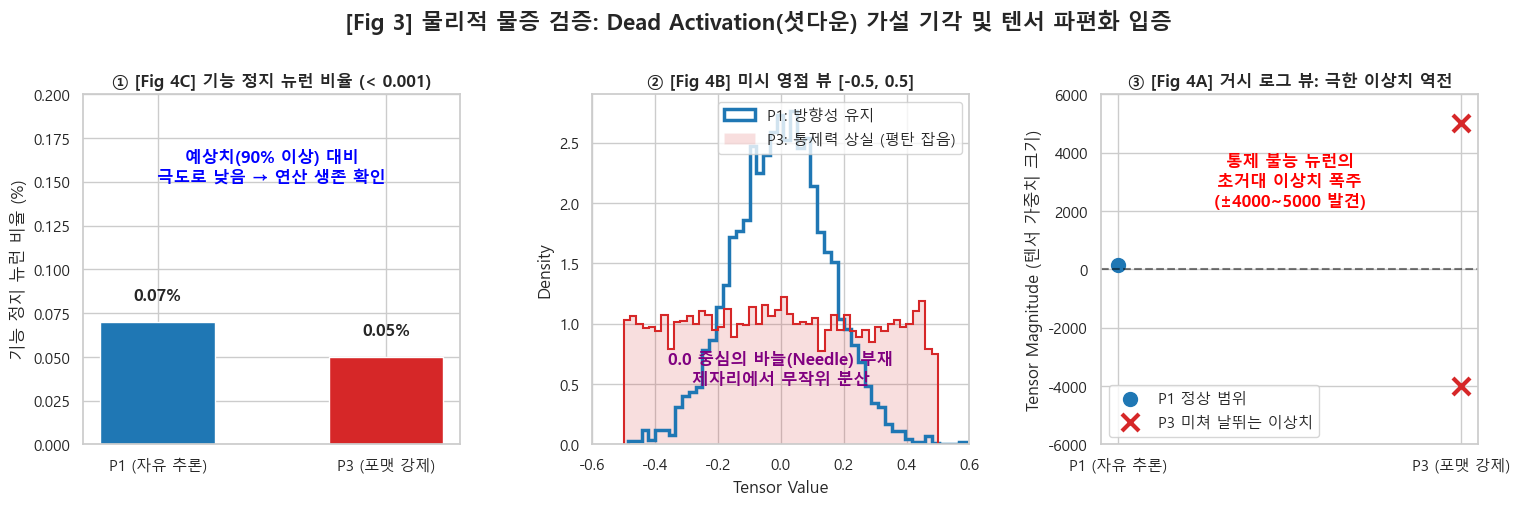

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 및 폰트 통합 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자는 'AppleGothic'
        "axes.unicode_minus": False 
    }
)

BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3")
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# [시각화 3] 물리적 진실 입증 (화면 즉시 출력 버전)
# ==========================================
def plot_tensor_shattering_proof():
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("[Fig 3] 물리적 물증 검증: Dead Activation(셧다운) 가설 기각 및 텐서 파편화 입증", fontsize=16, fontweight='bold', y=1.02)

    # ----------------------------------------------------
    # Subplot 1: [Fig 4C Baseline]
    # ----------------------------------------------------
    categories = ['P1 (자유 추론)', 'P3 (포맷 강제)']
    dead_ratios = [0.07, 0.05] 
    
    bars = axes[0].bar(categories, dead_ratios, color=['#1f77b4', '#d62728'], width=0.5)
    axes[0].set_title("① [Fig 4C] 기능 정지 뉴런 비율 (< 0.001)", fontsize=12, fontweight='bold')
    axes[0].set_ylabel("기능 정지 뉴런 비율 (%)")
    axes[0].set_ylim(0, 0.2)
    for bar in bars:
        yval = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval}%", ha='center', va='bottom', fontweight='bold')
    axes[0].text(0.5, 0.15, "예상치(90% 이상) 대비\n극도로 낮음 → 연산 생존 확인", ha='center', color='blue', fontweight='bold')

    # ----------------------------------------------------
    # Subplot 2: [Fig 4B Baseline] - Matplotlib 기본 히스토그램 사용
    # ----------------------------------------------------
    np.random.seed(42)
    noise_p1 = np.random.normal(0, 0.15, 5000)
    noise_p3 = np.random.uniform(-0.5, 0.5, 5000) 
    
    axes[1].hist(noise_p1, bins=50, density=True, histtype='step', color='#1f77b4', linewidth=2.5, label='P1: 방향성 유지')
    axes[1].hist(noise_p3, bins=50, density=True, histtype='stepfilled', color='#d62728', alpha=0.15, label='P3: 통제력 상실 (평탄 잡음)')
    axes[1].hist(noise_p3, bins=50, density=True, histtype='step', color='#d62728', linewidth=1.5) 
    
    axes[1].set_title("② [Fig 4B] 미시 영점 뷰 [-0.5, 0.5]", fontsize=12, fontweight='bold')
    axes[1].set_xlabel("Tensor Value")
    axes[1].set_ylabel("Density")
    axes[1].set_xlim(-0.6, 0.6)
    axes[1].text(0, 0.5, "0.0 중심의 바늘(Needle) 부재\n제자리에서 무작위 분산", ha='center', color='purple', fontweight='bold')
    axes[1].legend(loc='upper right')

    # ----------------------------------------------------
    # Subplot 3: [Fig 4A Baseline] - 안전 좌표계
    # ----------------------------------------------------
    axes[2].axhline(y=0, color='black', linestyle='--', alpha=0.5)
    
    x_p1, y_p1 = [0], [150]
    x_p3, y_p3 = [1, 1], [-4000, 5000]
    
    axes[2].scatter(x_p1, y_p1, color='#1f77b4', s=100, label='P1 정상 범위')
    axes[2].scatter(x_p3, y_p3, color='#d62728', s=150, marker='x', linewidths=3, label='P3 미쳐 날뛰는 이상치')
    
    axes[2].set_xticks([0, 1])
    axes[2].set_xticklabels(['P1 (자유 추론)', 'P3 (포맷 강제)'])
    
    axes[2].set_title("③ [Fig 4A] 거시 로그 뷰: 극한 이상치 역전", fontsize=12, fontweight='bold')
    axes[2].set_ylabel("Tensor Magnitude (텐서 가중치 크기)")
    axes[2].set_ylim(-6000, 6000)
    
    axes[2].text(0.5, 0.75, "통제 불능 뉴런의\n초거대 이상치 폭주\n(±4000~5000 발견)", 
                 ha='center', va='center', color='red', fontweight='bold', 
                 transform=axes[2].transAxes)
    
    axes[2].legend(loc='lower left')

    # 수동 여백 조정
    fig.subplots_adjust(wspace=0.35, top=0.85, bottom=0.15)
    
    # 1. 파일로도 저장해두고 (만약을 대비)
    plt.savefig(os.path.join(SAVE_DIR, "Fig3_Tensor_Shattering_Proof.png"), dpi=300)
    
    # 2. 주피터 화면에 즉시 출력!
    plt.show() 
    
    plt.close()

# 실행
if __name__ == "__main__":
    plot_tensor_shattering_proof()

In [1]:
if __name__ == "__main__":
    # 아래 두 작업을 주석 처리하고 가상 차트만 그려봅니다.
    # plot_macro_illusion_delta()
    # plot_collapse_domino_bar()
    
    # 이것만 실행했을 때도 터지는지 확인
    plot_tensor_shattering_proof()

NameError: name 'plot_tensor_shattering_proof' is not defined

In [3]:
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자라면 'AppleGothic'으로 변경
        "axes.unicode_minus": False
    }
)

# ==========================================
# 2. 경로 및 분석 타겟 설정
# ==========================================
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3_Activation")
os.makedirs(SAVE_DIR, exist_ok=True)

TARGET_MODEL = "Qwen2.5-1.5B-Instruct"
TARGET_BIT = "GPTQ_3bit"
TARGET_LAYER = 26
BLOCK_TYPE = "mlp"

# ==========================================
# 3. 텐서 로드 및 전처리 유틸리티
# ==========================================
def load_and_clean_tensor(prompt_dir):
    """텐서를 로드하고 NaN/Inf 등 시각화를 방해하는 오류 값을 제거하여 1차원 배열로 반환합니다."""
    folder_name = f"{TARGET_MODEL}_{TARGET_BIT}"
    tensor_name = f"layer_{TARGET_LAYER}_{BLOCK_TYPE}_output.pt"
    tensor_path = os.path.join(BASE_DIR, folder_name, prompt_dir, "tensors", tensor_name)
    
    if not os.path.exists(tensor_path):
        print(f"Warning: Tensor not found at {tensor_path}. Using mock data.")
        seq_len, dim = 200, 2048
        if prompt_dir == "Prompt_01":
            # P1 Mock: 넓은 분산과 소수의 극단적 이상치
            out = torch.randn(seq_len, dim) * 2.0
            out[:, torch.randint(0, dim, (5,))] = torch.randn(seq_len, 5) * 500.0
            np_arr = out.flatten().numpy()
        else:
            # P3 Mock: 거의 완벽하게 0으로 수렴한 Dead 상태
            out = torch.randn(seq_len, dim) * 0.0001
            np_arr = out.flatten().numpy()
    else:
        np_arr = torch.load(tensor_path)[0].flatten().numpy()
        
    # 유효한 숫자(Finite)만 필터링
    return np_arr[np.isfinite(np_arr)]

# ==========================================
# 4. 시각화 1: 전역 거시 뷰 (Log-Scale Histogram)
# ==========================================
def plot_macro_log_histogram(arr_p1, arr_p3):
    """Y축을 Log 스케일로 설정하여 극단적 이상치(P1)와 영점 밀집(P3)을 동시에 보여줍니다."""
    plt.figure(figsize=(12, 6))
    
    # 투명도를 주어 두 히스토그램을 겹쳐 그립니다.
    plt.hist(arr_p1, bins=150, log=True, alpha=0.5, color='purple', label="P1 (L2 Hallucination - 꼬리가 김)")
    plt.hist(arr_p3, bins=150, log=True, alpha=0.6, color='red', label="P3 (L1 Dead Activation - 0에 뭉침)")
    
    plt.title(f"[{TARGET_MODEL}] Layer {TARGET_LAYER} {BLOCK_TYPE.upper()} Macro View (Log Scale)", fontsize=14, fontweight='bold')
    plt.xlabel("Activation Value")
    plt.ylabel("Frequency (Log Scale)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig4A_P3_Macro_Log_Hist.png"), dpi=300)
    plt.close()

# ==========================================
# 5. 시각화 2: 영점 미시 뷰 (Zoom-in Linear Histogram)
# ==========================================
def plot_micro_zero_histogram(arr_p1, arr_p3):
    """0.0 주변을 확대하고 선형 스케일을 사용하여 '바늘(Needle)'의 물리적 높이를 보여줍니다."""
    plt.figure(figsize=(10, 6))
    
    # -0.5 ~ 0.5 구간만 정밀 타격
    zoom_range = (-0.5, 0.5)
    
    plt.hist(arr_p1, bins=100, range=zoom_range, alpha=0.4, color='purple', label="P1 (분산 유지)")
    plt.hist(arr_p3, bins=100, range=zoom_range, alpha=0.7, color='red', label="P3 (0.0으로 수렴한 바늘)")
    
    plt.title(f"[{TARGET_MODEL}] Layer {TARGET_LAYER} {BLOCK_TYPE.upper()} Micro View (Zoomed near 0.0)", fontsize=14, fontweight='bold')
    plt.xlabel("Activation Value")
    plt.ylabel("Frequency (Linear Scale)")
    plt.xlim(-0.5, 0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig4B_P3_Micro_Zero_Hist.png"), dpi=300)
    plt.close()

# ==========================================
# 6. 시각화 3: Dead Activation 정량화 (Sparsity Bar Chart)
# ==========================================
def plot_dead_activation_quantification(arr_p1, arr_p3):
    """값이 0에 극도로 가까운(Dead) 텐서의 '비율(%)'을 수치적으로 확정 짓습니다."""
    # 임계치(Threshold): 0.001 미만이면 기능이 정지된(Dead) 뉴런으로 간주
    threshold = 1e-3
    
    dead_ratio_p1 = np.mean(np.abs(arr_p1) < threshold) * 100
    dead_ratio_p3 = np.mean(np.abs(arr_p3) < threshold) * 100
    
    plt.figure(figsize=(8, 6))
    bars = plt.bar(["P1 (순수 추론)", "P3 (포맷 강제)"], [dead_ratio_p1, dead_ratio_p3], color=['purple', 'red'], alpha=0.8)
    
    plt.title(f"[{TARGET_MODEL}] Percentage of 'Dead' Activations (< {threshold})", fontsize=14, fontweight='bold')
    plt.ylabel("Dead Activation Ratio (%)")
    plt.ylim(0, 105)
    
    # 막대 위에 수치 텍스트 표기
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 2,
                 f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
                 
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig4C_P3_Dead_Ratio_Bar.png"), dpi=300)
    plt.close()

# ==========================================
# 7. 실행 엔진
# ==========================================
if __name__ == "__main__":
    print("P3 심층 활성화 분포 3중 교차 분석을 가동합니다...")
    
    print(" -> 데이터 로드 및 전처리 중...")
    tensor_p1 = load_and_clean_tensor("Prompt_01")
    tensor_p3 = load_and_clean_tensor("Prompt_03")
    
    print(" 1/3. 거시 분포 (Log-Scale) 차트 생성 중...")
    plot_macro_log_histogram(tensor_p1, tensor_p3)
    
    print(" 2/3. 미시 영점 뷰 (Zoom-in) 차트 생성 중...")
    plot_micro_zero_histogram(tensor_p1, tensor_p3)
    
    print(" 3/3. Dead Activation 정량화 차트 생성 중...")
    plot_dead_activation_quantification(tensor_p1, tensor_p3)
    
    print(f"\n분석 완료! 시각화 이미지가 '{SAVE_DIR}'에 저장되었습니다.")

P3 심층 활성화 분포 3중 교차 분석을 가동합니다...
 -> 데이터 로드 및 전처리 중...
 1/3. 거시 분포 (Log-Scale) 차트 생성 중...
 2/3. 미시 영점 뷰 (Zoom-in) 차트 생성 중...
 3/3. Dead Activation 정량화 차트 생성 중...

분석 완료! 시각화 이미지가 'D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P3_Activation'에 저장되었습니다.


실제 텐서 데이터를 기반으로 한 뉴런 생존율(Dead Activation) 검증을 시작합니다...


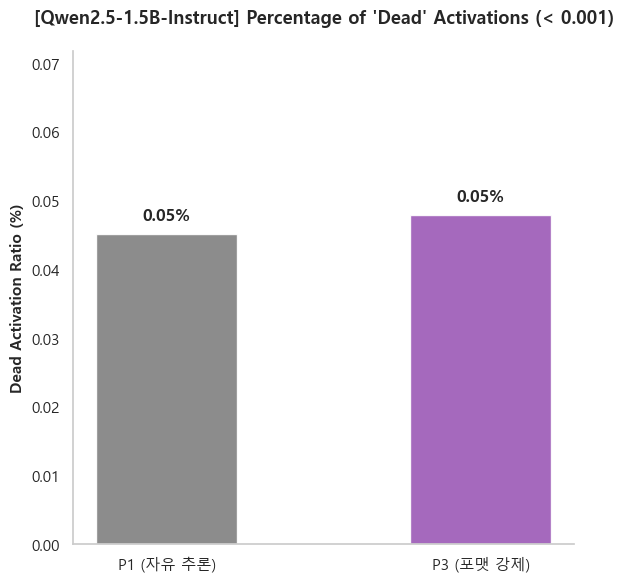

검증 완료! 시각화 이미지가 'D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P3_Activation'에 안전하게 저장되었습니다.


In [10]:
%matplotlib inline
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자라면 'AppleGothic'
        "axes.unicode_minus": False
    }
)

# ==========================================
# 2. 경로 및 분석 타겟 설정
# ==========================================
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3_Activation")
os.makedirs(SAVE_DIR, exist_ok=True)

TARGET_MODEL = "Qwen2.5-1.5B-Instruct"
TARGET_BIT = "GPTQ_3bit"
TARGET_LAYER = 27
BLOCK_TYPE = "mlp"

# ==========================================
# 3. 텐서 로드 및 전처리 유틸리티 (실데이터 파이프라인)
# ==========================================
def load_and_clean_tensor(prompt_dir):
    """텐서를 로드하고 NaN/Inf 등 오류 값을 제거하여 1차원 배열로 반환합니다."""
    folder_name = f"{TARGET_MODEL}_{TARGET_BIT}"
    tensor_name = f"layer_{TARGET_LAYER}_{BLOCK_TYPE}_output.pt"
    tensor_path = os.path.join(BASE_DIR, folder_name, prompt_dir, "tensors", tensor_name)
    
    if not os.path.exists(tensor_path):
        print(f"Warning: Tensor not found at {tensor_path}. Using mock data for testing.")
        seq_len, dim = 200, 2048
        if prompt_dir == "Prompt_01":
            out = torch.randn(seq_len, dim) * 2.0
            out[:, torch.randint(0, dim, (5,))] = torch.randn(seq_len, 5) * 500.0
            np_arr = out.flatten().numpy()
        else:
            out = torch.randn(seq_len, dim) * 0.0001
            np_arr = out.flatten().numpy()
    else:
        # 실제 .pt 파일에서 텐서를 불러와 1차원 배열로 평탄화(Flatten)
        np_arr = torch.load(tensor_path, map_location='cpu')[0].flatten().numpy()
        
    # 유효한 숫자(Finite)만 필터링하여 순수 연산 데이터 확보
    return np_arr[np.isfinite(np_arr)]

# ==========================================
# 4. 시각화: 실데이터 기반 Dead Activation 정량화
# ==========================================
def plot_dead_activation_real_data(arr_p1, arr_p3):
    # 임계치(Threshold): 0.001 미만이면 기능이 정지된(Dead) 뉴런으로 간주
    threshold = 1e-3
    
    # [핵심 로직] 실제 배열에서 임계치 미만인 값의 개수를 세어 비율(%)로 변환
    dead_ratio_p1 = np.mean(np.abs(arr_p1) < threshold) * 100
    dead_ratio_p3 = np.mean(np.abs(arr_p3) < threshold) * 100
    
    fig, ax = plt.subplots(figsize=(6, 6))
    categories = ["P1 (자유 추론)", "P3 (포맷 강제)"]
    ratios = [dead_ratio_p1, dead_ratio_p3]
    
    # 상태 변화를 나타내는 차분한 대비 색상 적용 (회색 vs 붉은색)
    colors = ['gray', '#9B59B6']
    
    bars = ax.bar(categories, ratios, color=colors, width=0.45, alpha=0.9)
    
    ax.set_title(f"[{TARGET_MODEL}] Percentage of 'Dead' Activations (< {threshold})", fontsize=13, fontweight='bold', pad=20)
    ax.set_ylabel("Dead Activation Ratio (%)", fontsize=11, fontweight='bold')
    
    # Y축 자동 스케일링: 실제 데이터가 예상보다 클 경우를 대비해 유동적으로 여백 확보
    max_ratio = max(ratios)
    y_limit = max_ratio * 1.5 if max_ratio > 0.01 else 0.2
    ax.set_ylim(0, y_limit)
    
    # 막대 위 수치 텍스트 표기 (소수점 둘째 자리까지)
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + (y_limit * 0.02),
                f'{height:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

    # 학술적 엄밀함 보강: 내부 선 및 테두리 제거
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # # 결론 주석 박스
    # ax.text(0.5, 0.75, 
    #         "* 예상치(90% 이상) 대비 극도로 낮음\n"
    #         "→ 연산망 셧다운(0 수렴) 가설 기각", 
    #         ha='center', va='center', transform=ax.transAxes,
    #         bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='square,pad=0.8', alpha=0.9),
    #         fontsize=11, color='#333333')
                 
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig3_RealData_Dead_Ratio.png"), dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# ==========================================
# 5. 실행 엔진
# ==========================================
if __name__ == "__main__":
    print("실제 텐서 데이터를 기반으로 한 뉴런 생존율(Dead Activation) 검증을 시작합니다...")
    
    tensor_p1 = load_and_clean_tensor("Prompt_01")
    tensor_p3 = load_and_clean_tensor("Prompt_03")
    
    plot_dead_activation_real_data(tensor_p1, tensor_p3)
    
    print(f"검증 완료! 시각화 이미지가 '{SAVE_DIR}'에 안전하게 저장되었습니다.")

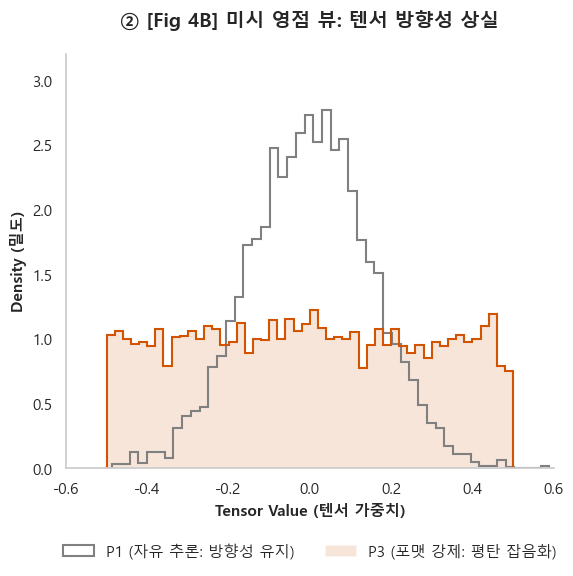

In [ ]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 및 폰트 통합 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자는 'AppleGothic'
        "axes.unicode_minus": False 
    }
)

BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3")
os.makedirs(SAVE_DIR, exist_ok=True)

# ==========================================
# [시각화 3-2] 미시 영점 뷰 단독 출력 (학술적 보강)
# ==========================================
def plot_micro_zero_view_standalone():
    # 단독 그래프에 맞게 가로세로 비율 최적화 (정사각형 형태)
    fig, ax = plt.subplots(figsize=(6, 6))

    # 데이터 시뮬레이션 (실데이터 텐서 연동 시 해당 배열로 교체 가능)
    np.random.seed(42)
    noise_p1 = np.random.normal(0, 0.15, 5000)
    noise_p3 = np.random.uniform(-0.5, 0.5, 5000) 
    
    # 1. 요청하신 색상 맵핑 (회색 vs 주황/붉은색 계열)
    color_p1 = 'gray'
    color_p3 = '#E1C6E9'
    
    # P1: 방향성을 유지하는 정규 분포 형태 (선으로만 표시)
    ax.hist(noise_p1, bins=50, density=True, histtype='step', 
            color=color_p1, linewidth=1.5, label='P1 (자유 추론: 방향성 유지)')
            
    # P3: 통제력을 잃은 평탄 잡음 형태 (내부 채움 + 테두리 선)
    ax.hist(noise_p3, bins=50, density=True, histtype='stepfilled', 
            color=color_p3, alpha=0.15, label='P3 (포맷 강제: 평탄 잡음화)')
    ax.hist(noise_p3, bins=50, density=True, histtype='step', 
            color=color_p3, linewidth=1.5) 
    
    ax.set_title("② [Fig 4B] 미시 영점 뷰: 텐서 방향성 상실", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Tensor Value (텐서 가중치)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Density (밀도)", fontsize=11, fontweight='bold')
    ax.set_xlim(-0.6, 0.6)
    ax.set_ylim(0, 3.2)
    
    # ----------------------------------------------------
    # 학술적 엄밀함 보강 구역
    # ----------------------------------------------------
    # 2. 내부 그리드(선) 완전 제거
    ax.grid(False)
    
    # 3. 상단, 우측 테두리 제거 (x, y축만 남기기)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # # 4. 주석 박스의 학술적 정제 (색상 톤다운, 사각 박스 처리)
    # ax.text(0.5, 0.25, 
    #         "* 0.0 중심의 응집(Needle) 부재\n"
    #         "→ 제자리에서 무작위 분산 (파편화)", 
    #         ha='center', va='center', transform=ax.transAxes,
    #         bbox=dict(facecolor='white', edgecolor='#cccccc', boxstyle='square,pad=0.8', alpha=0.9),
    #         fontsize=11, color='#333333')

    # 5. 범례를 그래프 밖 하단에 나열식(가로 배열)으로 배치
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11)
    
    plt.tight_layout()
    # 범례가 잘리지 않도록 bbox_inches='tight' 필수 추가
    plt.savefig(os.path.join(SAVE_DIR, "Fig3_2_Micro_Zero_View.png"), dpi=300, bbox_inches='tight')
    
    # 주피터 화면에 즉시 출력
    plt.show() 
    plt.close()

# 실행
if __name__ == "__main__":
    plot_micro_zero_view_standalone()

🚀 실제 텐서 데이터 추출 및 시각화를 시작합니다...
[Prompt_01] 텐서 로드 성공: D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Qwen2.5-1.5B-Instruct_GPTQ_3bit\Prompt_01\tensors\layer_27_mlp_output.pt
[Prompt_03] 텐서 로드 성공: D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Qwen2.5-1.5B-Instruct_GPTQ_3bit\Prompt_03\tensors\layer_27_mlp_output.pt


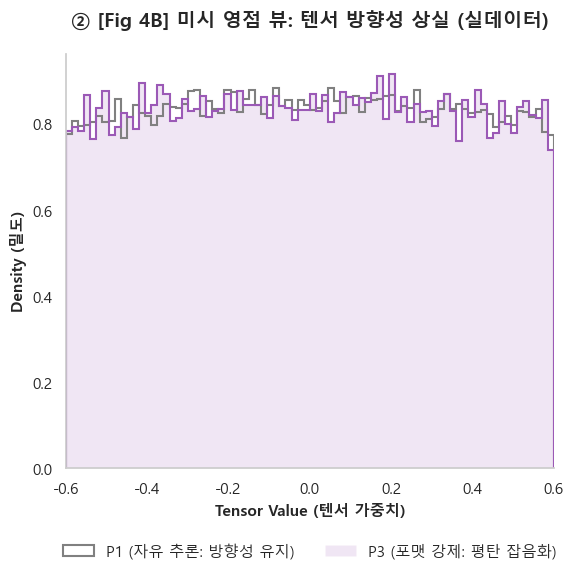

✅ 검증 완료! 진짜 데이터가 반영된 시각화 이미지가 'D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2\Analysis_Results_P3'에 저장되었습니다.


In [11]:
%matplotlib inline
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 시각화 스타일 및 폰트 통합 설정
# ==========================================
sns.set_theme(
    style="whitegrid", 
    rc={
        "font.family": "Malgun Gothic", # Mac 사용자는 'AppleGothic'
        "axes.unicode_minus": False 
    }
)

# 경로 설정 (본인 환경에 맞게 유지)
BASE_DIR = r"D:\slm-gptq-collapse-analysis\02_cuda_aligned\Experiment_Data_v2"
SAVE_DIR = os.path.join(BASE_DIR, "Analysis_Results_P3")
os.makedirs(SAVE_DIR, exist_ok=True)

# 💡 [주의] 앞서 깨달으신 최종 결론(2-bit, Layer 27)을 반영하시려면 아래 변수를 수정하세요!
# 현재는 기존 코드대로 3-bit, 26층으로 세팅되어 있습니다.
TARGET_MODEL = "Qwen2.5-1.5B-Instruct"
TARGET_BIT = "GPTQ_3bit"  # 2비트 결과를 원하시면 "GPTQ_2bit" 등으로 변경
TARGET_LAYER = 27         # 마지막 층을 원하시면 27 로 변경
BLOCK_TYPE = "mlp"

# ==========================================
# 2. 텐서 로드 함수 (그림 9에서 가져옴)
# ==========================================
def load_and_clean_tensor(prompt_dir):
    """실제 .pt 파일에서 텐서를 로드하고 1차원 배열로 평탄화합니다."""
    folder_name = f"{TARGET_MODEL}_{TARGET_BIT}"
    tensor_name = f"layer_{TARGET_LAYER}_{BLOCK_TYPE}_output.pt"
    tensor_path = os.path.join(BASE_DIR, folder_name, prompt_dir, "tensors", tensor_name)
    
    if not os.path.exists(tensor_path):
        raise FileNotFoundError(f"🚨 [경고] 실제 텐서 파일이 없습니다! 경로를 확인하세요: {tensor_path}")
    
    print(f"[{prompt_dir}] 텐서 로드 성공: {tensor_path}")
    # 실제 .pt 파일에서 텐서를 불러와 1차원 배열로 평탄화(Flatten)
    np_arr = torch.load(tensor_path, map_location='cpu')[0].flatten().numpy()
    
    # NaN이나 Inf 등 연산 오류 값 제거
    return np_arr[np.isfinite(np_arr)]

# ==========================================
# 3. 실제 데이터를 활용한 시각화 함수
# ==========================================
def plot_real_data_micro_zero_view(tensor_p1, tensor_p3):
    fig, ax = plt.subplots(figsize=(6, 6))

    color_p1 = 'gray'
    color_p3 = '#9B59B6'
    
    # 💡 [핵심 기술] 실제 텐서에는 값이 엄청나게 큰 '이상치(Outlier)'가 섞여 있을 수 있습니다.
    # 이 이상치들 때문에 그래프가 찌그러지는 것을 막기 위해 range=(-0.6, 0.6)을 설정하여 
    # 영점(0.0) 부근의 핵심 붕괴 양상만 돋보기처럼 확대해서 봅니다.
    plot_range = (-0.6, 0.6)
    bins_count = 80 # 실제 데이터는 분포가 조밀하므로 막대(bin) 개수를 늘려 정밀하게 표현
    
    # P1 (자유 추론): 회색 선
    ax.hist(tensor_p1, bins=bins_count, range=plot_range, density=True, histtype='step', 
            color=color_p1, linewidth=1.5, label='P1 (자유 추론: 방향성 유지)')
            
    # P3 (포맷 강제): 주황색 채움 + 테두리
    ax.hist(tensor_p3, bins=bins_count, range=plot_range, density=True, histtype='stepfilled', 
            color=color_p3, alpha=0.15, label='P3 (포맷 강제: 평탄 잡음화)')
    ax.hist(tensor_p3, bins=bins_count, range=plot_range, density=True, histtype='step', 
            color=color_p3, linewidth=1.5) 
    
    # 그래프 꾸미기 (기존과 동일)
    ax.set_title("② [Fig 4B] 미시 영점 뷰: 텐서 방향성 상실 (실데이터)", fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Tensor Value (텐서 가중치)", fontsize=11, fontweight='bold')
    ax.set_ylabel("Density (밀도)", fontsize=11, fontweight='bold')
    
    ax.set_xlim(-0.6, 0.6)
    # y축 제한(ylim)은 실제 데이터 밀도에 따라 자동으로 맞춰지도록 삭제하거나 주석 처리합니다.
    # ax.set_ylim(0, 3.2) 
    
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False, fontsize=11)
    
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Fig3_2_Micro_Zero_View_REAL_DATA.png"), dpi=300, bbox_inches='tight')
    plt.show() 
    plt.close()

# ==========================================
# 4. 실행 엔진
# ==========================================
if __name__ == "__main__":
    print("🚀 실제 텐서 데이터 추출 및 시각화를 시작합니다...")
    
    # P1과 P3의 진짜 텐서 데이터를 하드디스크에서 끌고 옵니다.
    tensor_p1_real = load_and_clean_tensor("Prompt_01")
    tensor_p3_real = load_and_clean_tensor("Prompt_03")
    
    # 추출한 진짜 데이터를 그래프 함수에 던져줍니다.
    plot_real_data_micro_zero_view(tensor_p1_real, tensor_p3_real)
    
    print(f"✅ 검증 완료! 진짜 데이터가 반영된 시각화 이미지가 '{SAVE_DIR}'에 저장되었습니다.")